In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from scipy import stats

In [50]:

data = pd.read_csv('data (1).csv')




In [51]:
print(data.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [52]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [53]:

print(data.columns)


Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [54]:
print(data.isnull().sum())


id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [55]:
data.drop(['Unnamed: 32', 'id'], axis=1, inplace=True , errors='ignore')
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

In [56]:
y = data['diagnosis'].values
x_data = data.drop(['diagnosis'], axis=1)

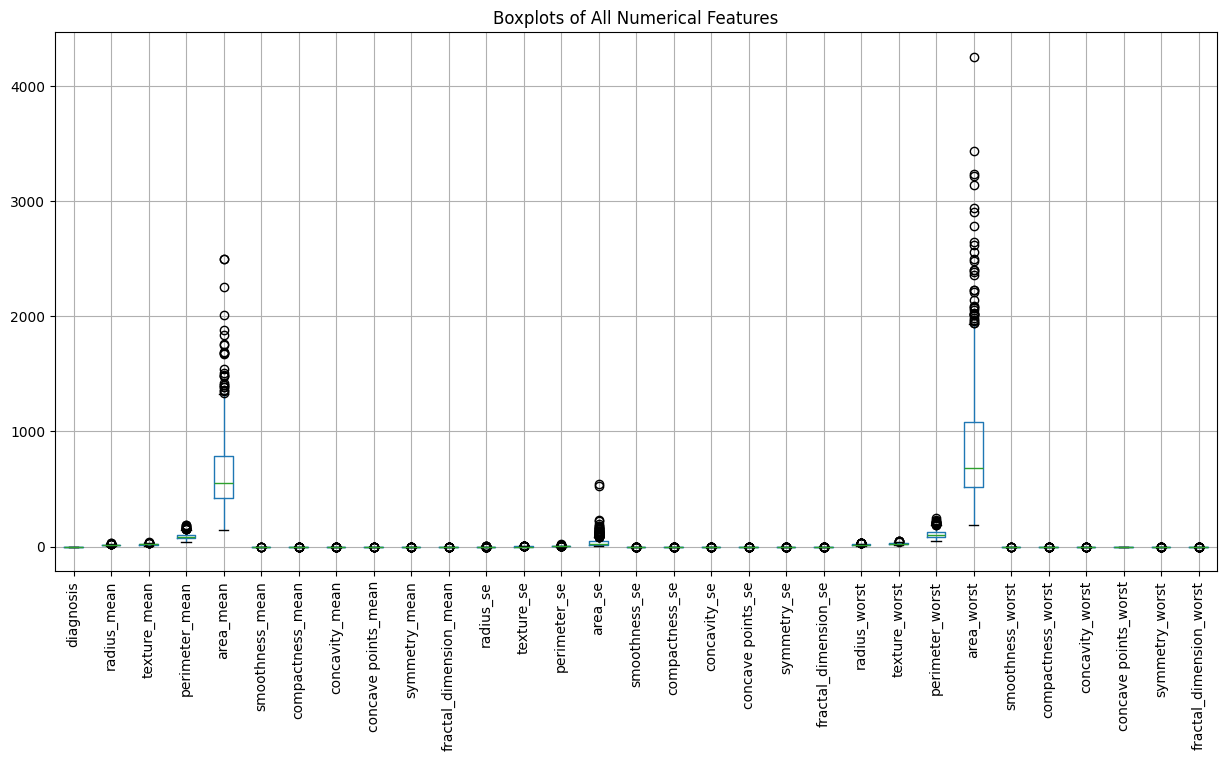

In [57]:
plt.figure(figsize=(15, 7))
data.boxplot()
plt.title("Boxplots of All Numerical Features")
plt.xticks(rotation=90)
plt.show()

Columns chosen for selective standardization: ['area_mean', 'perimeter_mean', 'area_worst', 'perimeter_worst']

 Standardization applied ONLY to selected outlier-heavy columns.



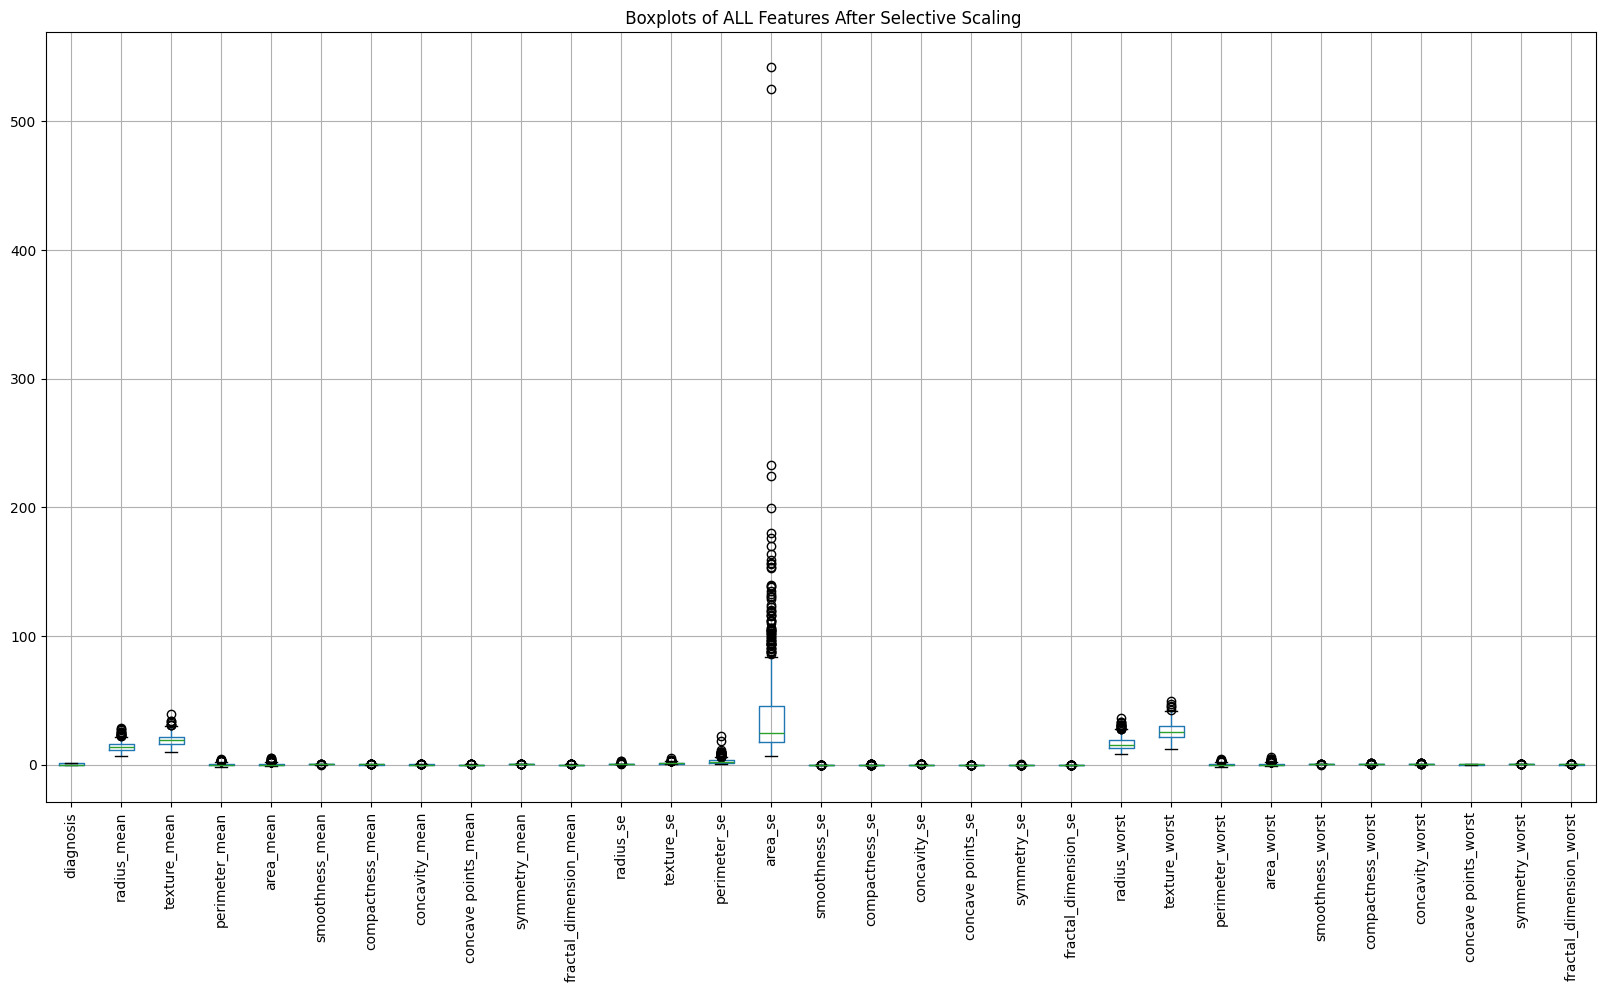

In [58]:
outlier_columns = [
    'area_mean',
    'perimeter_mean',
    'area_worst',
    'perimeter_worst'
]

print("Columns chosen for selective standardization:", outlier_columns)


scaler = StandardScaler()
data_scaled = data.copy()
data_scaled[outlier_columns] = scaler.fit_transform(data[outlier_columns])
print("\n Standardization applied ONLY to selected outlier-heavy columns.\n")


plt.figure(figsize=(20, 10))
data_scaled.boxplot()
plt.title(" Boxplots of ALL Features After Selective Scaling")
plt.xticks(rotation=90)
plt.show()

In [59]:
x = (x_data - x_data.min()) / (x_data.max() - x_data.min())
x

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,0.690000,0.428813,0.678668,0.566490,0.526948,0.296055,0.571462,0.690358,0.336364,0.132056,...,0.623266,0.383262,0.576174,0.452664,0.461137,0.178527,0.328035,0.761512,0.097575,0.105667
565,0.622320,0.626987,0.604036,0.474019,0.407782,0.257714,0.337395,0.486630,0.349495,0.113100,...,0.560655,0.699094,0.520892,0.379915,0.300007,0.159997,0.256789,0.559450,0.198502,0.074315
566,0.455251,0.621238,0.445788,0.303118,0.288165,0.254340,0.216753,0.263519,0.267677,0.137321,...,0.393099,0.589019,0.379949,0.230731,0.282177,0.273705,0.271805,0.487285,0.128721,0.151909
567,0.644564,0.663510,0.665538,0.475716,0.588336,0.790197,0.823336,0.755467,0.675253,0.425442,...,0.633582,0.730277,0.668310,0.402035,0.619626,0.815758,0.749760,0.910653,0.497142,0.452315


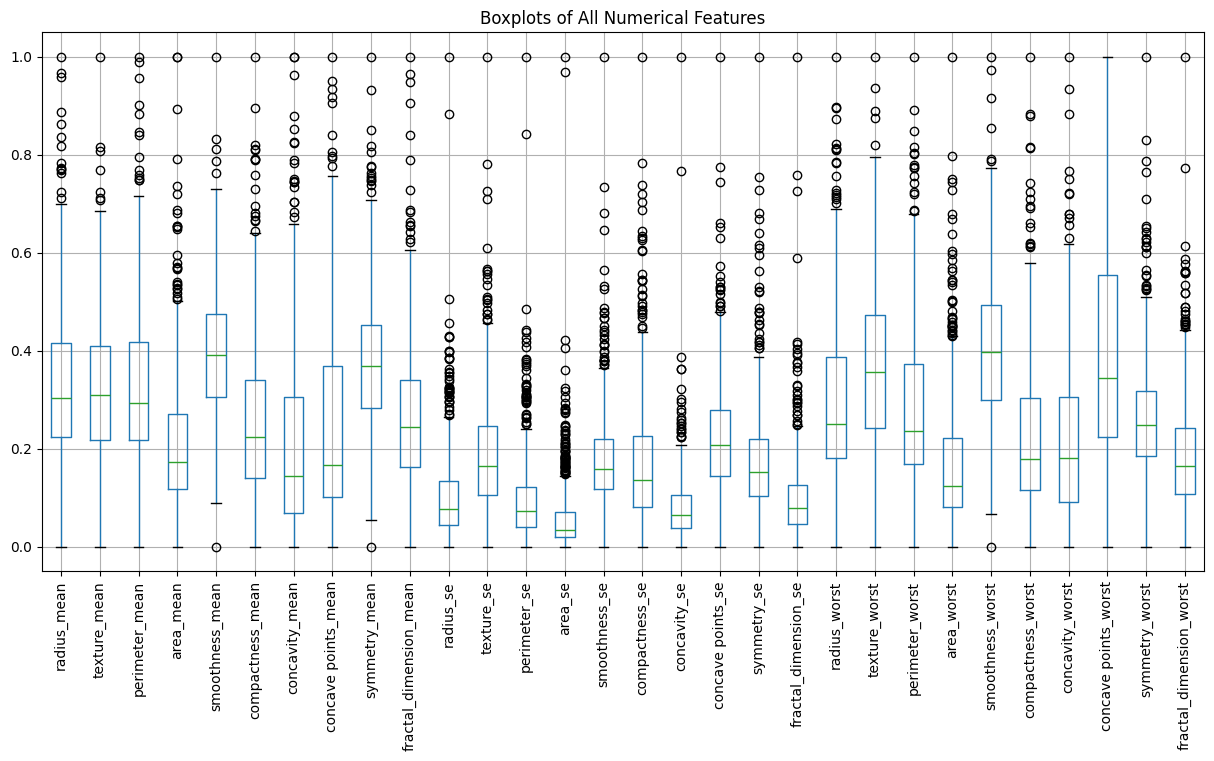

In [60]:
plt.figure(figsize=(15, 7))

x.boxplot(rot=90)
plt.title("Boxplots of All Numerical Features")
plt.show()

In [61]:
train_data, temp_data = train_test_split(
    data, test_size=0.7, random_state=42, stratify=data['diagnosis']
)
test1_data, test2_data = train_test_split(
    temp_data, test_size=0.5, random_state=42, stratify=temp_data['diagnosis']
)

print(f"Train: {train_data.shape}, Test1: {test1_data.shape}, Test2: {test2_data.shape}")


def separate_features_labels(df):
    X = df.drop('diagnosis', axis=1).values
    y = df['diagnosis'].values.reshape(-1, 1)
    return X, y

X_train, y_train = separate_features_labels(train_data)
X_test1, y_test1 = separate_features_labels(test1_data)
X_test2, y_test2 = separate_features_labels(test2_data)

X_train_bias = np.c_[np.ones((X_train.shape[0],1)), X_train]
X_test1_bias = np.c_[np.ones((X_test1.shape[0],1)), X_test1]
X_test2_bias = np.c_[np.ones((X_test2.shape[0],1)), X_test2]


Train: (170, 31), Test1: (199, 31), Test2: (200, 31)


In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, weights, lambda_reg=0.0, penalty='L2'):
    m = len(y)
    h = sigmoid(np.dot(X, weights))
    cost = (-1/m) * np.sum(y*np.log(h + 1e-9) + (1-y)*np.log(1-h + 1e-9))
    if penalty=='L2':
        cost += (lambda_reg/(2*m)) * np.sum(weights[1:]**2)
    elif penalty=='L1':
        cost += (lambda_reg/m) * np.sum(np.abs(weights[1:]))
    return cost

def gradient_descent(X, y, lr=0.01, epochs=2000, lambda_reg=0.0, penalty='L2'):
    m, n = X.shape
    weights = np.zeros((n,1))
    cost_history = []

    for i in range(epochs):
        z = np.dot(X, weights)
        h = sigmoid(z)
        grad = np.dot(X.T, (h - y)) / m

        if penalty=='L2':
            grad[1:] += (lambda_reg / m) * weights[1:]
        elif penalty=='L1':
            grad[1:] += (lambda_reg / m) * np.sign(weights[1:])

        weights -= lr * grad
        cost_history.append(compute_cost(X, y, weights, lambda_reg, penalty))
    return weights, cost_history

In [63]:
def predict(X, weights, threshold=0.5):
    return (sigmoid(np.dot(X, weights)) >= threshold).astype(int)

def evaluate_model(X, y, weights, dataset_name="Dataset"):
    y_pred = predict(X, weights)
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    print(f"\n {dataset_name} Metrics:")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {dataset_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


In [ ]:

penalties = ['L1', 'L2']
lambda_values = [0.0, 0.01, 0.1, 0.5, 0.09]

best_f1 = 0
best_penalty = None
best_lambda = None
best_weights = None

print(" Starting hyperparameter tuning...")


for pen in penalties:
    for lam in lambda_values:
        weights, _ = gradient_descent(
            X_train_bias, y_train, lr=0.1, epochs=2000, lambda_reg=lam, penalty=pen
        )
      
        y_pred_test1 = predict(X_test1_bias, weights)
        f1 = f1_score(y_test1, y_pred_test1)

        if f1 > best_f1:
            best_f1 = f1
            best_penalty = pen
            best_lambda = lam
            best_weights = weights

print(f"\n Best Hyperparameters: Penalty = {best_penalty}, λ = {best_lambda}, F1 on Test1 = {best_f1:.4f}")




🔍 Starting hyperparameter tuning...


C:\Users\Abdullah Laptop\AppData\Local\Temp\ipykernel_14368\3711076561.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


C:\Users\Abdullah Laptop\AppData\Local\Temp\ipykernel_14368\3711076561.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\Abdullah Laptop\AppData\Local\Temp\ipykernel_14368\3711076561.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\Abdullah Laptop\AppData\Local\Temp\ipykernel_14368\3711076561.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\Abdullah Laptop\AppData\Local\Temp\ipykernel_14368\3711076561.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\Abdullah Laptop\AppData\Local\Temp\ipykernel_14368\3711076561.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\Abdullah Laptop\AppData\Local\Temp\ipykernel_14368\3711076561.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\Abdullah Laptop\AppData\Local\Temp\ipykernel_14368\3711076561.py:2: RuntimeWarning: o


🏆 Best Hyperparameters: Penalty = L1, λ = 0.1, F1 on Test1 = 0.8919



 Train Data Metrics:
Accuracy: 0.9000 | Precision: 0.8382 | Recall: 0.9048 | F1: 0.8702


C:\Users\Abdullah Laptop\AppData\Local\Temp\ipykernel_14368\3711076561.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


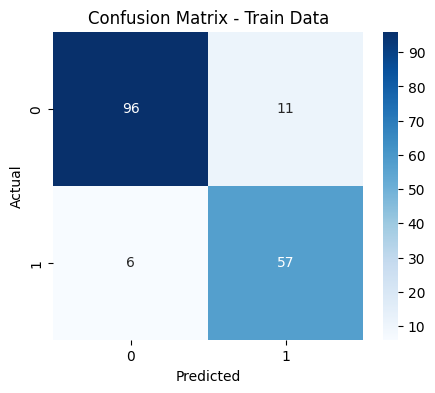

C:\Users\Abdullah Laptop\AppData\Local\Temp\ipykernel_14368\3711076561.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))



 Test1 Data Metrics:
Accuracy: 0.9196 | Precision: 0.8919 | Recall: 0.8919 | F1: 0.8919


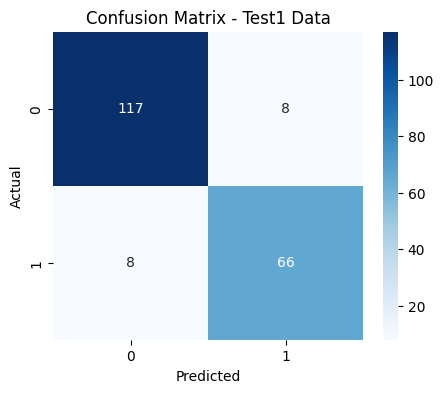

C:\Users\Abdullah Laptop\AppData\Local\Temp\ipykernel_14368\3711076561.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))



 Test2 Data Metrics:
Accuracy: 0.9000 | Precision: 0.8481 | Recall: 0.8933 | F1: 0.8701


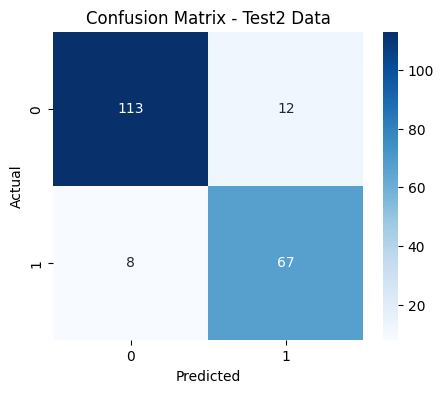

In [65]:

train_metrics = evaluate_model(X_train_bias, y_train, best_weights, "Train Data")
test1_metrics = evaluate_model(X_test1_bias, y_test1, best_weights, "Test1 Data")
test2_metrics = evaluate_model(X_test2_bias, y_test2, best_weights, "Test2 Data")